<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/29_outlier_removal_using_zscore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/placement_outlier.csv")

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

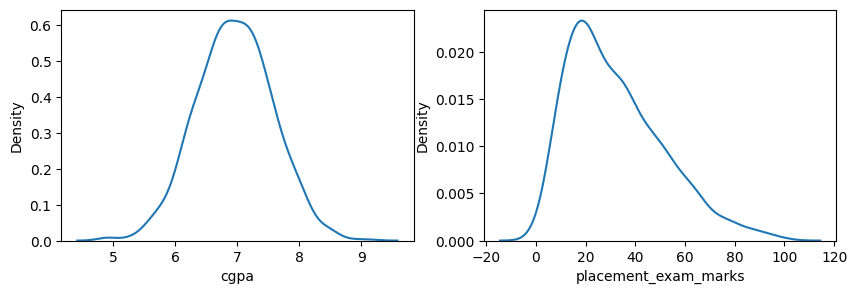

In [12]:
plt.figure(figsize=(10,3))
plt.subplot(121)
sns.kdeplot(df["cgpa"])

plt.subplot(122)
sns.kdeplot(df["placement_exam_marks"])

In [19]:
print("Mean of CGPA",df["cgpa"].mean())
print("Std of CGPA",df["cgpa"].std())
print("Min of CGPA",df["cgpa"].min())
print("Max of CGPA",df["cgpa"].max())

Mean of CGPA 6.96124
Std of CGPA 0.6158978751323894
Min of CGPA 4.89
Max of CGPA 9.12


In [21]:
upper_boundary=df["cgpa"].mean()+3*df["cgpa"].std()
lower_boundary=df["cgpa"].mean()-3*df["cgpa"].std()

In [22]:
upper_boundary

np.float64(8.808933625397168)

In [23]:
lower_boundary

np.float64(5.113546374602832)

In [26]:
#find outlier
df[(df["cgpa"]>upper_boundary) | (df["cgpa"]<lower_boundary)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


**Trimming**

In [30]:
#find outlier
new_df=df[(df["cgpa"]<upper_boundary) & (df["cgpa"]>lower_boundary)]

In [31]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# Approach 2

# Calculating the Zscore

In [32]:
df["cgpa_zscore"]= (df["cgpa"]-df["cgpa"].mean())/df["cgpa"].std()

In [33]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [34]:
df["cgpa_zscore"].min()

-3.362960132886934

In [36]:
df["cgpa_zscore"].max()

3.5050616135604726

In [37]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [38]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [39]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [40]:
# Trimming
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

**Capping**

In [41]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [42]:
upper_limit

np.float64(8.808933625397168)

In [43]:
df["cgpa"]=np.where(
    df["cgpa"]>upper_limit, upper_limit,
    np.where(df["cgpa"]<lower_limit,lower_limit,  df['cgpa'])

)

In [44]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


In [45]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934
